In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [2]:
df = pd.read_csv("/content/NetflixOriginals.csv",encoding = "ISO-8859-1")
df

,Title,Genre,Premiere,Runtime,IMDB Score,Language
0,Enter the Anime,Documentary,"August 5, 2019",58,2.5,English/Japanese
1,Dark Forces,Thriller,"August 21, 2020",81,2.6,Spanish
2,The App,Science fiction/Drama,"December 26, 2019",79,2.6,Italian
3,The Open House,Horror thriller,"January 19, 2018",94,3.2,English
4,Kaali Khuhi,Mystery,"October 30, 2020",90,3.4,Hindi
...,...,...,...,...,...,...
579,Taylor Swift: Reputation Stadium Tour,Concert Film,"December 31, 2018",125,8.4,English
580,Winter on Fire: Ukraine's Fight for Freedom,Documentary,"October 9, 2015",91,8.4,English/Ukranian/Russian
581,Springsteen on Broadway,One-man show,"December 16, 2018",153,8.5,English
582,Emicida: AmarElo - It's All For Yesterday,Documentary,"December 8, 2020",89,8.6,Portuguese


In [3]:
df.describe()

,Runtime,IMDB Score
count,584.000000,584.000000
mean,93.577055,6.271747
std,27.761683,0.979256
min,4.000000,2.500000
25%,86.000000,5.700000
50%,97.000000,6.350000
75%,108.000000,7.000000
max,209.000000,9.000000


In [4]:
df.isnull().sum()

,0
Title,0
Genre,0
Premiere,0
Runtime,0
IMDB Score,0
Language,0


In [7]:
df['Premiere'] = pd.to_datetime(df['Premiere'])

# columns year, month and weekday
df['year']    = df['Premiere'].dt.year
df['month']   = df['Premiere'].dt.month_name()
df['weekday'] = df['Premiere'].dt.day_name()

df.head()

,Title,Genre,Premiere,Runtime,IMDB Score,Language,year,month,weekday
0,Enter the Anime,Documentary,2019-08-05,58,2.5,English/Japanese,2019,August,Monday
1,Dark Forces,Thriller,2020-08-21,81,2.6,Spanish,2020,August,Friday
2,The App,Science fiction/Drama,2019-12-26,79,2.6,Italian,2019,December,Thursday
3,The Open House,Horror thriller,2018-01-19,94,3.2,English,2018,January,Friday
4,Kaali Khuhi,Mystery,2020-10-30,90,3.4,Hindi,2020,October,Friday


In [6]:
df['Premiere'] = df['Premiere'].str.replace('.',',',regex=False)
df['Premiere'] = pd.to_datetime(df['Premiere'])

### Q1. What are the most common genres among Netflix Originals?

In [37]:
top_genres = (df['Genre'].str.split("/").explode().value_counts()).head(10)
top_genres.column = ['Genre','Count']
top_genres

,count
Genre,
Documentary,159
Drama,81
Comedy,57
Romantic comedy,40
Thriller,38
Science fiction,16
Comedy-drama,15
Horror,12
Crime drama,12


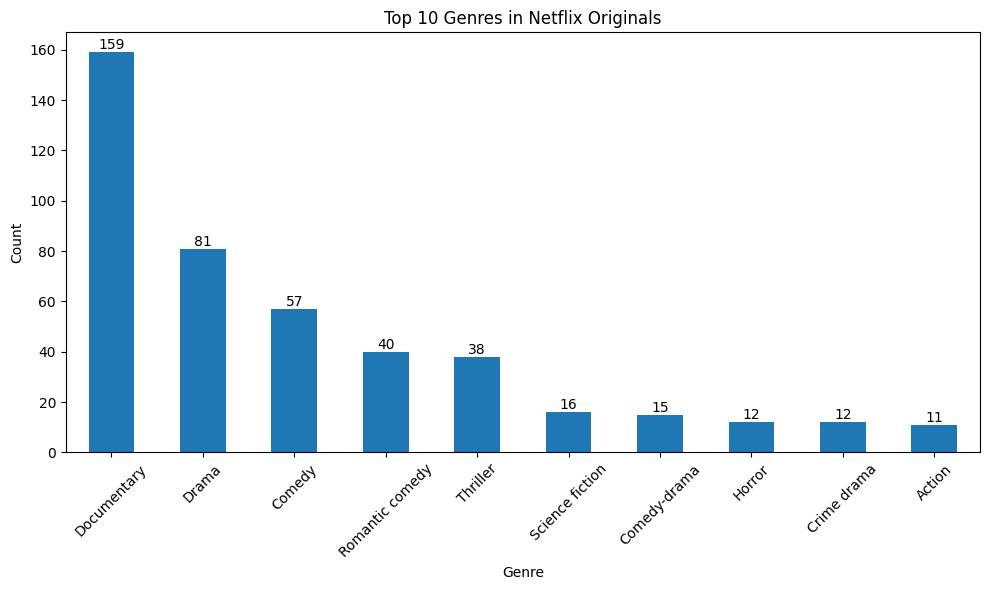

In [29]:
plt.figure(figsize=(10, 6))
bar = top_genres.plot(kind='bar')

bar.bar_label(plt.gca().containers[0])

plt.title('Top 10 Genres in Netflix Originals')
plt.xlabel('Genre')
plt.ylabel('Count')

plt.xticks(rotation=45)
plt.tight_layout()


### Q2 : Which year had the highest number of Netflix Original releases?

In [36]:
year_counts = df['year'].value_counts().head(10)
year_counts.column = ['Year','Count']
year_counts

,count
year,
2020,183
2019,125
2018,99
2021,71
2017,66
2016,30
2015,9
2014,1


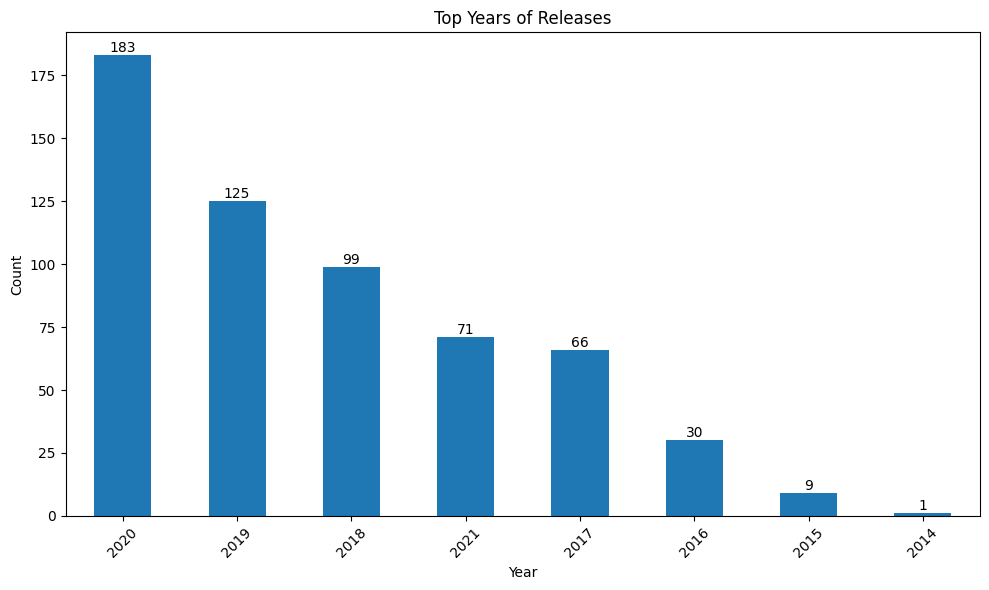

In [38]:
plt.figure(figsize=(10, 6))
bar = year_counts.plot(kind='bar')

bar.bar_label(plt.gca().containers[0])

plt.title('Top Years of Releases')
plt.xlabel('Year')
plt.ylabel('Count')

plt.xticks(rotation=45)
plt.tight_layout()

### Q3 : What is the average IMDb score of all Netflix Originals?

In [44]:
print("Average IMDb score of Netflix Originals : ", df['IMDB Score'].mean().round(1))

Average IMDb score of Netflix Originals :  6.27


### Q4 : Which movies or shows have the highest and lowest IMDb scores?

In [51]:
highest_score = df.loc[df['IMDB Score'] == df['IMDB Score'].max(),['Title','IMDB Score']]
highest_score

,Title,IMDB Score
583,David Attenborough: A Life on Our Planet,9.0


In [50]:
lowest_score = df.loc[df['IMDB Score'] == df['IMDB Score'].min(),['Title','IMDB Score']]
lowest_score


,Title,IMDB Score
0,Enter the Anime,2.5


### Q5. How many Netflix Originals were released each month?

In [83]:
monthly_release = df.groupby(['year', 'month'])['Title'].count().reset_index(name='Number_of_Releases')
monthly_release

,year,month,Number_of_Releases
0,2014,December,1
1,2015,December,2
2,2015,July,1
3,2015,June,1
4,2015,May,2
...,...,...,...
65,2021,April,18
66,2021,February,13
67,2021,January,16
68,2021,March,12


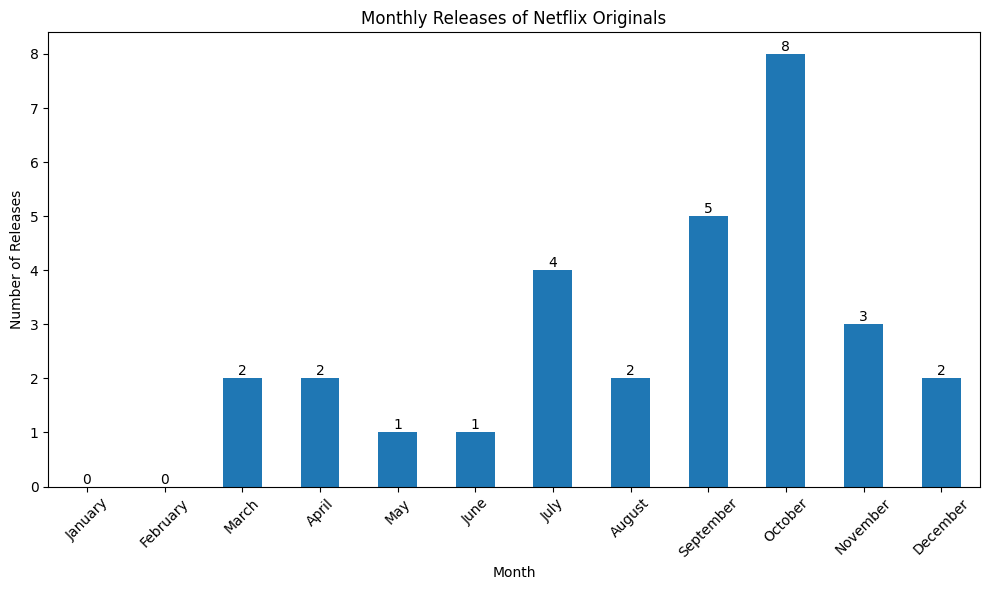

In [86]:
monthly_release = df[df['year'] == 2016]['month'].value_counts()

monthly_release = monthly_release.reindex(['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December'])

plt.figure(figsize=(10, 6))
bar = monthly_release.plot(kind='bar')

bar.bar_label(plt.gca().containers[0])

plt.title('Monthly Releases of Netflix Originals')
plt.xlabel('Month')
plt.ylabel('Number of Releases')

plt.xticks(rotation=45)
plt.tight_layout()

### Q6. Which language appears most frequently in the dataset?

In [92]:
top_language = df['Language'].str.split("/").explode().value_counts().head(10)
top_language


,count
Language,
English,422
Spanish,39
Hindi,35
French,21
Italian,14
Portuguese,12
Indonesian,9
Japanese,8
Korean,7


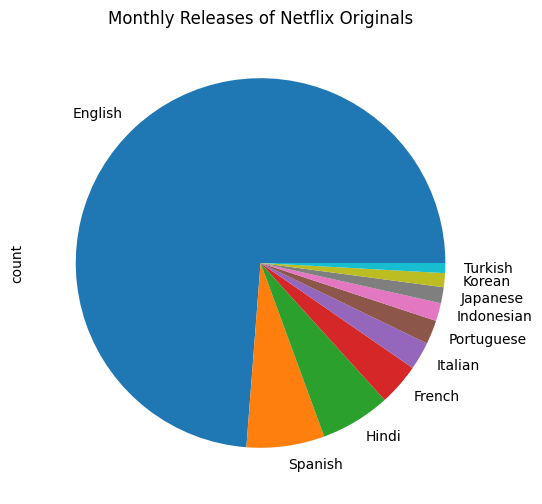

In [101]:
plt.figure(figsize=(10, 6))
pie = top_language.head(10).plot(kind='pie')
plt.title('Monthly Releases of Netflix Originals')
plt.show()

### Q7 : What is the average runtime of Netflix Originals?

In [104]:
print ("Average runtime of Netflix Originals : ", df['Runtime'].mean().round(1) , "minutes")

Average runtime of Netflix Originals :  93.6 minutes


### Q8 : Which genres tend to have the longest runtimes?

In [112]:
genre = df['Genre'].str.split("/").explode()
genre

,Genre
0,Documentary
1,Thriller
2,Science fiction
2,Drama
3,Horror thriller
...,...
579,Concert Film
580,Documentary
581,One-man show
582,Documentary


In [117]:
runtime_bygenres = (df.assign(Genre=df['Genre'].str.split('/')).explode('Genre').groupby('Genre')['Runtime'].mean().sort_values(ascending=False))
runtime_bygenres

,Runtime
Genre,
Anthology,149.000000
Heist film,149.000000
Zombie,148.000000
War drama,145.500000
Horror anthology,144.000000
...,...
Interview,23.666667
Drama,17.000000
Musical,15.000000
